In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv("Dataset/messy_HR_data.csv")

In [4]:
df.head(10)

,Name,Age,Salary,Gender,Department,Position,Joining Date,Performance Score,Email,Phone Number
0,grace,25,50000,Male,HR,Manager,"April 5, 2018",D,email@example.com,NaN
1,david,NaN,65000,Female,Finance,Director,20-02-2020,F,user@domain.com,123-456-7890
2,hannah,35,SIXTY THOUSAND,Female,Sales,Director,01/15/2020,C,email@example.com,098-765-4321
3,eve,NaN,50000,Female,IT,Manager,"April 5, 2018",A,name@company.org,
4,grace,NaN,NAN,Female,Finance,Manager,01/15/2020,F,name@company.org,098-765-4321
5,jack,NaN,65000,Other,Marketing,Director,03-25-2019,F,user@domain.com,NaN
6,charlie,NaN,50000,Male,Marketing,Clerk,2019.12.01,B,NaN,123-456-7890
7,grace,40,50000,Other,HR,Director,03-25-2019,C,NaN,
8,hannah,40,SIXTY THOUSAND,Female,Marketing,Manager,01/15/2020,C,user@domain.com,123-456-7890
9,eve,thirty,NAN,Other,Finance,Assistant,20-02-2020,A,NaN,


In [5]:
df.tail(10)

,Name,Age,Salary,Gender,Department,Position,Joining Date,Performance Score,Email,Phone Number
990,hannah,thirty,SIXTY THOUSAND,Male,HR,Assistant,03-25-2019,C,email@example.com,
991,frank,25,55000,Other,Marketing,Manager,03-25-2019,C,NaN,NaN
992,frank,thirty,SIXTY THOUSAND,Female,Marketing,Analyst,20-02-2020,A,email@example.com,555-555-5555
993,hannah,35,NAN,Other,Finance,Clerk,"April 5, 2018",B,NaN,123-456-7890
994,grace,thirty,50000,Female,Marketing,Manager,"April 5, 2018",A,NaN,NaN
995,jack,50,65000,Female,HR,Manager,20-02-2020,F,NaN,098-765-4321
996,jack,thirty,50000,Male,Finance,Analyst,"April 5, 2018",C,NaN,555-555-5555
997,hannah,thirty,70000,Male,IT,Assistant,01/15/2020,D,user@domain.com,NaN
998,bob,25,65000,Other,Marketing,Manager,"April 5, 2018",D,email@example.com,NaN
999,ivy,thirty,SIXTY THOUSAND,Male,Finance,Manager,20-02-2020,C,user@domain.com,123-456-7890


# Data Cleaning

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Name               1000 non-null   object
 1   Age                841 non-null    object
 2   Salary             1000 non-null   object
 3   Gender             1000 non-null   object
 4   Department         1000 non-null   object
 5   Position           1000 non-null   object
 6   Joining Date       1000 non-null   object
 7   Performance Score  1000 non-null   object
 8   Email              610 non-null    object
 9   Phone Number       815 non-null    object
dtypes: object(10)
memory usage: 78.3+ KB


In [7]:
df.shape

(1000, 10)

In [8]:
df.describe()

,Name,Age,Salary,Gender,Department,Position,Joining Date,Performance Score,Email,Phone Number
count,1000,841,1000,1000,1000,1000,1000,1000,610,815
unique,10,5,6,3,5,5,5,5,3,4
top,alice,thirty,65000,Male,Finance,Assistant,20-02-2020,B,user@domain.com,123-456-7890
freq,118,176,184,355,218,214,232,225,213,236


In [9]:
df.isnull().sum()

Name                   0
Age                  159
Salary                 0
Gender                 0
Department             0
Position               0
Joining Date           0
Performance Score      0
Email                390
Phone Number         185
dtype: int64

In [10]:
for col in df.columns:
    if df[col].nunique() < 20:
        print (df[col].value_counts())
        print("---"*40)

Name
alice       118
charlie     110
jack        107
eve         107
hannah      100
frank        96
david        94
grace        94
ivy          91
bob          83
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------
Age
thirty    176
25        171
40        170
35        163
50        161
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------
Salary
65000             184
70000             173
55000             172
 NAN              167
50000             161
SIXTY THOUSAND    143
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------
Gender
Male      355
Other     332
Female    313
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------------

In [11]:
df["Salary"] = df["Salary"].replace(" NAN " , np.nan)

In [12]:
df["Age"].unique()

array(['25', nan, '35', '40', 'thirty', '50'], dtype=object)

In [13]:
df.dropna().shape

(336, 10)

if we drop all null values then shape will be (336, 10) that is more than 50 % of data

In [14]:
df[df.duplicated()].shape

(0, 10)

## Fix inconsistence data

In [15]:
df["Age"]=df["Age"].replace("thirty",30)

In [16]:
df["Salary"].unique()

array(['50000', '65000', 'SIXTY THOUSAND', nan, '70000', '55000'],
      dtype=object)

In [17]:
df["Salary"] = df["Salary"].replace("SIXTY THOUSAND" , 60000)

In [18]:
df["Email"].unique()

array(['email@example.com', 'user@domain.com', 'name@company.org', nan],
      dtype=object)

In [19]:
df['Email'] = df['Email'].replace("",np.nan)

In [20]:
df["Phone Number"].unique()

array([nan, '123-456-7890', '098-765-4321', ' ', '555-555-5555'],
      dtype=object)

In [21]:
df["Phone Number"] = df["Phone Number"].replace(" ",np.nan)

## Correct The Data Types

In [22]:
df["Age"] = pd.to_numeric(df['Age'])

In [23]:
df["Salary"] = pd.to_numeric(df["Salary"] , errors="coerce")

In [24]:
df["Joining Date"] = pd.to_datetime(df["Joining Date"], format="mixed", errors="coerce")

In [25]:
df["Phone Number"] = df["Phone Number"].astype("string")

## Handle  Missing Value

In [26]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [27]:
df["Salary"] = df["Salary"].fillna(df["Salary"].mean()).round(2)

In [28]:
df['Email'] = df['Email'].fillna("Unkown")

In [29]:
df["Phone Number"] = df["Phone Number"].fillna("Unkown")

In [30]:
df["Age"] = df["Age"].astype(int)

### There are Zero duplicate values

### Label Encoding

In [31]:
le = LabelEncoder()
df["Performance Score"] = le.fit_transform(df["Performance Score"])

In [32]:
df["Performance Score"].unique()

array([3, 4, 2, 0, 1])

# Data Analysis

In [33]:
#How many employees are in the dataset?
df.shape[0]

1000

There are 1000 Employees in Dataset

In [34]:
#Average, minimum and maximum age
df["Age"].agg(["mean" , "max" , "min"])

mean    35.675
max     50.000
min     25.000
Name: Age, dtype: float64

Average Age is 36 , Maximun is 50 and Minimum is 25

In [35]:
#Average salary of all employees
df["Salary"].mean()

np.float64(60216.08703)

Average Salary of all employee is 60217

In [36]:
print("Number of Employees in Each Department")
df["Department"].value_counts()

Number of Employees in Each Department


Department
Finance      218
Sales        202
HR           200
IT           193
Marketing    187
Name: count, dtype: int64

Most of the Employees are in Finance department

In [37]:
print("Number of Employees in Each Gender")
df["Gender"].value_counts()

Number of Employees in Each Gender


Gender
Male      355
Other     332
Female    313
Name: count, dtype: int64

Male has highest count among all other Gender

In [38]:
#Average salary for each department
df.groupby("Department")["Salary"].mean().round(2)

Department
Finance      60018.70
HR           60255.25
IT           59825.22
Marketing    60092.77
Sales        60877.96
Name: Salary, dtype: float64

In [39]:
#Which department has the highest average salary?
df.groupby("Department")["Salary"].mean().round(2).sort_values(ascending=False)

Department
Sales        60877.96
HR           60255.25
Marketing    60092.77
Finance      60018.70
IT           59825.22
Name: Salary, dtype: float64

Sales Department Has highest average salary

In [40]:
#Average salary for each position
df.groupby("Position")["Salary"].mean()

Position
Analyst      60154.484897
Assistant    59829.100514
Clerk        60061.124059
Director     60778.723971
Manager      60276.788710
Name: Salary, dtype: float64

In [41]:
#Average performance score for each department
df.groupby("Department")["Performance Score"].value_counts()

Department  Performance Score
Finance     1                    49
            4                    48
            3                    44
            0                    40
            2                    37
HR          2                    48
            4                    41
            1                    40
            3                    38
            0                    33
IT          1                    47
            0                    40
            2                    40
            3                    34
            4                    32
Marketing   1                    46
            0                    41
            2                    35
            3                    35
            4                    30
Sales       4                    50
            1                    43
            3                    39
            0                    38
            2                    32
Name: count, dtype: int64

In [42]:
#Find the 5 highest-paid employees
df.nlargest(5, "Salary")[["Name" ,"Salary","Department"]]

,Name,Salary,Department
10,david,70000.0,Marketing
11,hannah,70000.0,Finance
23,frank,70000.0,Marketing
25,alice,70000.0,Sales
26,jack,70000.0,Finance


In [43]:
#How many employees joined in each year?
df["Joining Date"].dt.year.value_counts()
#dt is used to access date/time in pandas

Joining Date
2020    429
2019    385
2018    186
Name: count, dtype: int64

Most of the employees join in 2020

# Data Visualization

## 1.Univariate Analysis

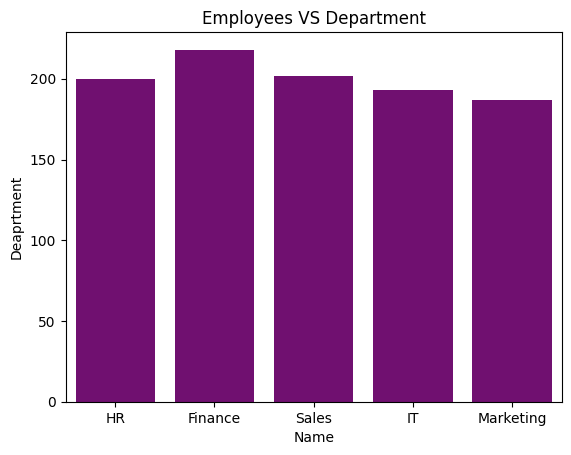

In [70]:
#Create a bar chart showing the number of employees in each department

sns.countplot(data=df , x="Department"  , color="Purple" )
plt.title("Employees VS Department")
plt.xlabel("Name")
plt.ylabel("Deaprtment")
plt.show()

Highest Employees are in Finance Department
Lowest Employees are in Marketing Department 

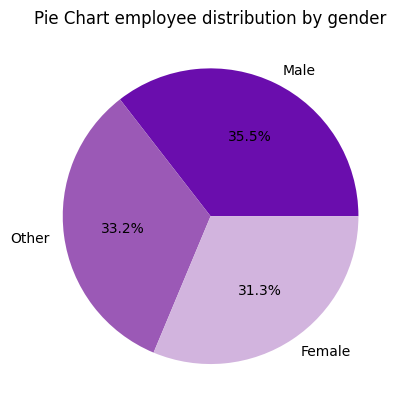

In [45]:
#Create a pie chart showing employee distribution by gender
gender_count = df["Gender"].value_counts()

plt.pie(gender_count , labels=gender_count.index , autopct = "%1.1f%%" , colors = ["#6A0DAD", "#9B59B6", "#D2B4DE"])
plt.title("Pie Chart employee distribution by gender")
plt.show()

Male employees have the highest percentage (35.5%), while female employees have the lowest (31.3%). The difference between the three groups is relatively small.

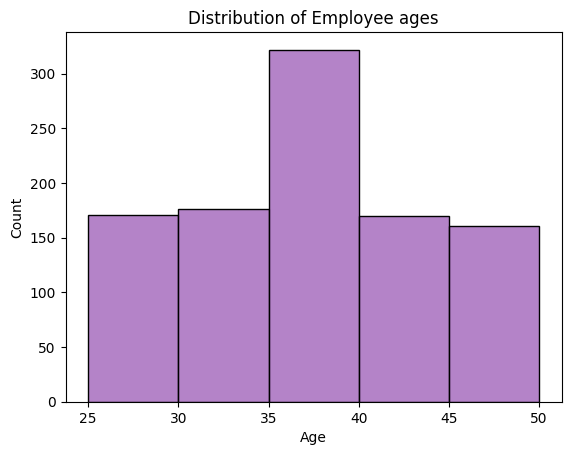

In [46]:
#Create a histogram showing the distribution of employee ages.

sns.histplot(data = df , x = "Age" , color="#9B59B6" , bins=5)
plt.title("Distribution of Employee ages")
plt.show()

Most employees are between 35 and 40 years old, as this age group has the highest number of employees. The number of employees in the other age groups is relatively similar.

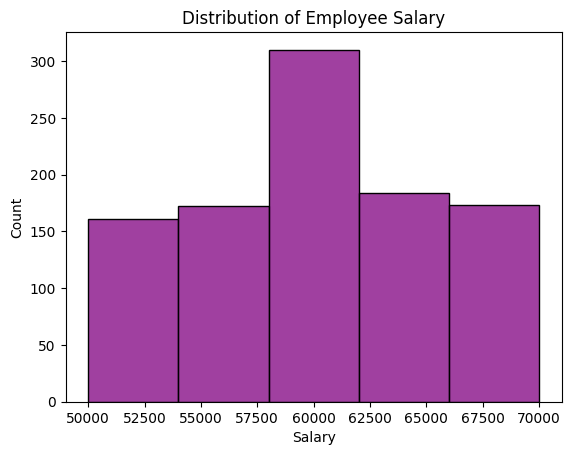

In [47]:
#Create a histogram showing the distribution of salaries.
sns.histplot(data = df , x = "Salary" , color="Purple" , bins=5)
plt.title("Distribution of Employee Salary")
plt.show()

Most employees have salaries in the range of approximately ₹58,000–₹62,000, which has the highest number of employees. The salary distribution ranges from around ₹50,000 to ₹70,000.

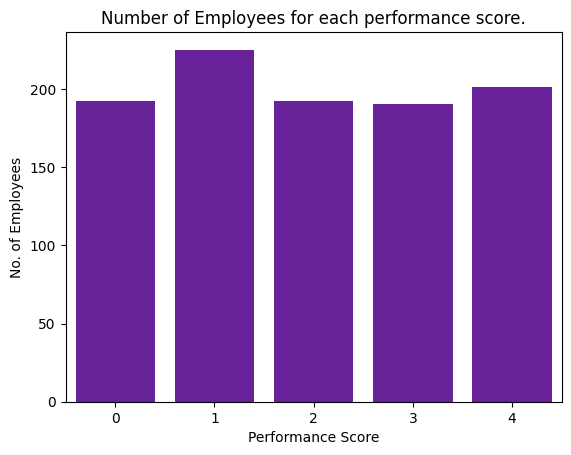

In [48]:
#Create a bar chart showing the number of employees for each performance score.

sns.countplot(data = df , x = "Performance Score" , color="#6A0DAD")
plt.title("Number of Employees for each performance score.")
plt.xlabel("Performance Score")
plt.ylabel("No. of Employees")
plt.show()

Performance Score 1 has the highest number of employees, while Performance Scores 0, 2, and 3 have similar numbers of employees. Overall, employees are fairly evenly distributed across the performance scores.

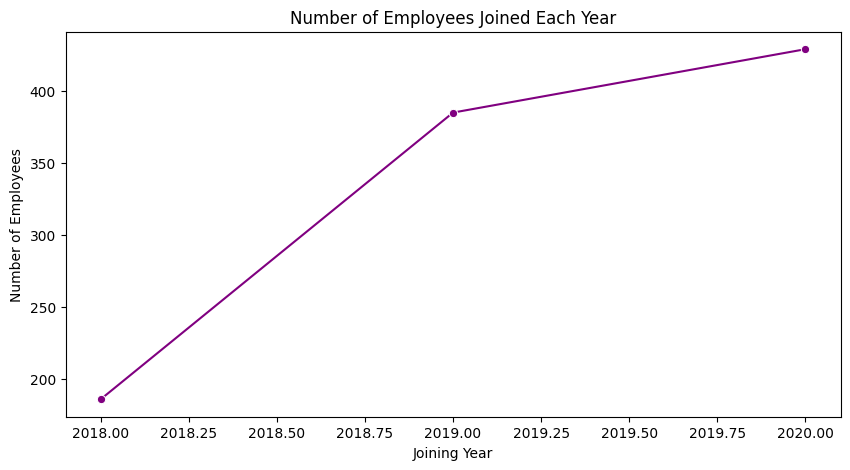

In [72]:
#Create a line chart showing the number of employees who joined each year.

df["Joining Year"] = df["Joining Date"].dt.year

joining_year = df["Joining Year"].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.lineplot(x = joining_year.index, y = joining_year.values, marker="o" ,color = "purple")
plt.title("Number of Employees Joined Each Year")
plt.xlabel("Joining Year")
plt.ylabel("Number of Employees")

plt.show()

The number of employees joining the company increased each year. The highest number of employees joined in 2020, while the lowest number joined in 2018.

## 2.Bivariate Analysis

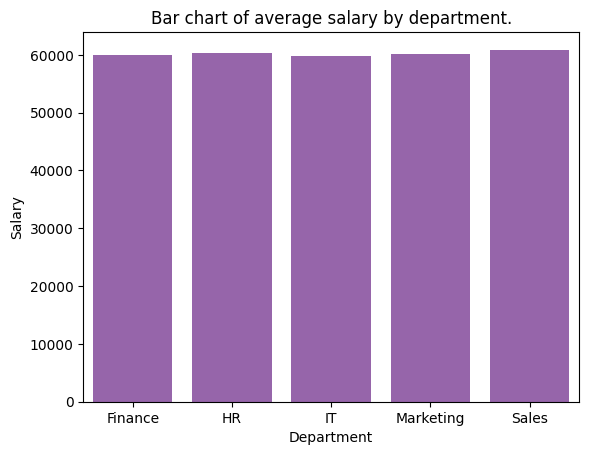

In [51]:
#Create a bar chart showing average salary by department.
avg_sal = df.groupby("Department")["Salary"].mean().round(2).reset_index()
sns.barplot(data = avg_sal , x = "Department" , y = "Salary" , color="#9B59B6")
plt.title("Bar chart of average salary by department.")
plt.xlabel("Department")
plt.ylabel("Salary")
plt.show()

The average salary is relatively similar across all departments. Sales has the highest average salary, while Finance has the lowest average salary. The difference between departments is small.

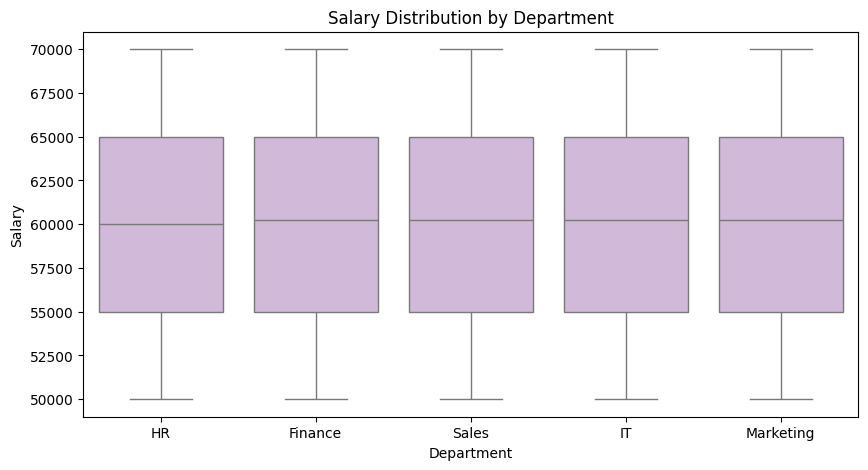

In [54]:
#Create a boxplot showing salary distribution for each department.

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="Department", y="Salary" , color="#D2B4DE")
plt.title("Salary Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Salary")
#plt.xticks(rotation=45)

plt.show()

Salary distributions are very similar across all departments. The median salary is around ₹60,000 for each department, and salaries range approximately from ₹50,000 to ₹70,000. There are no obvious outliers.

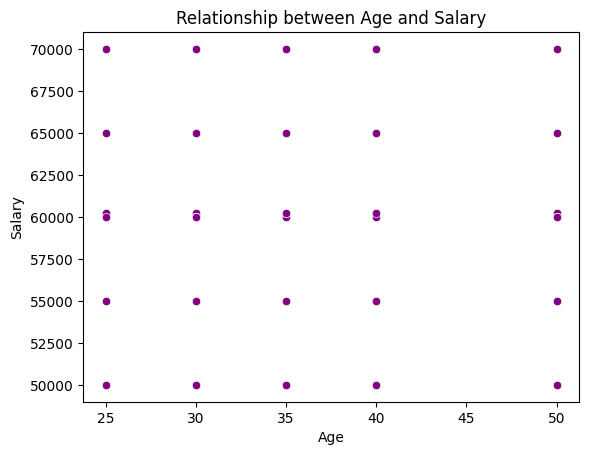

In [56]:
#Create a scatter plot showing the relationship between Age and Salary.

sns.scatterplot(data = df , x = "Age" , y = "Salary" , color="purple")
plt.title("Relationship between Age and Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

There is no clear relationship between age and salary in this dataset. Employees of different ages can have similar salaries, and the same salary levels occur across different age groups

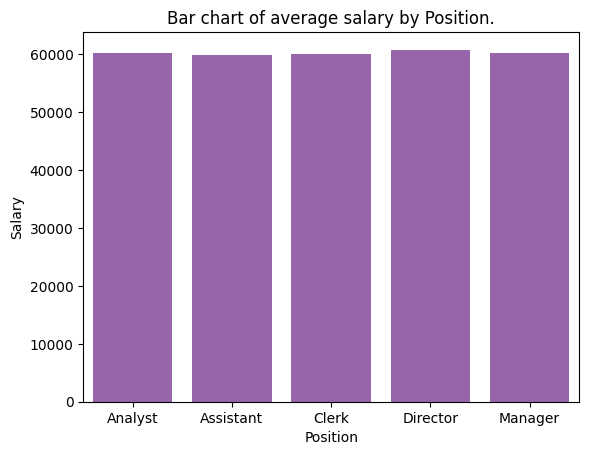

In [57]:
#Create a bar chart comparing average salary across different positions.

avg_sal = df.groupby("Position")["Salary"].mean().round(2).reset_index()
sns.barplot(data = avg_sal , x = "Position" , y = "Salary" , color="#9B59B6")
plt.title("Bar chart of average salary by Position.")
plt.xlabel("Position")
plt.ylabel("Salary")
plt.show()

Director has the highest average salary, while Assistant has the lowest. However, the difference in average salary between the positions is very small, showing that salaries are relatively similar across positions.

## Multivariate Analysis

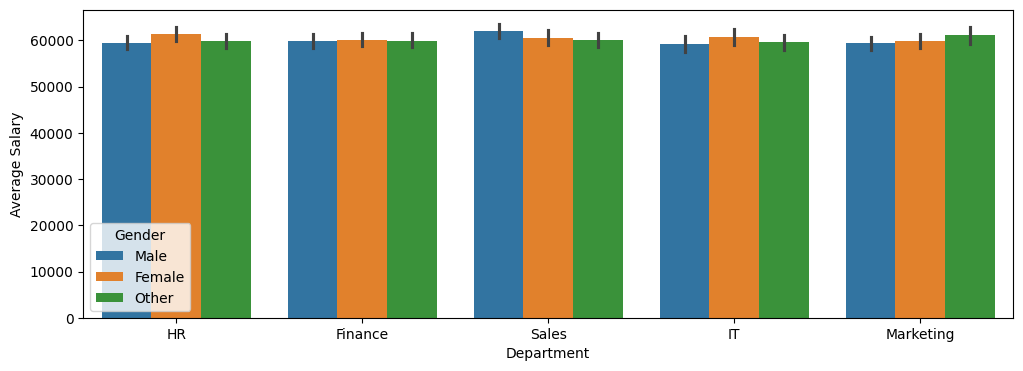

In [63]:
#Create a grouped bar chart showing average salary by department, separated by gender.

plt.figure(figsize = (12,4))
sns.barplot(data = df , x = "Department" , y = "Salary" , hue = "Gender")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.show()

Average salary varies slightly across genders within different departments. Female employees have the highest average salary in HR and IT, while Male employees have the highest average salary in Sales. In Marketing, Other employees have the highest average salary. Overall, the differences are relatively small.

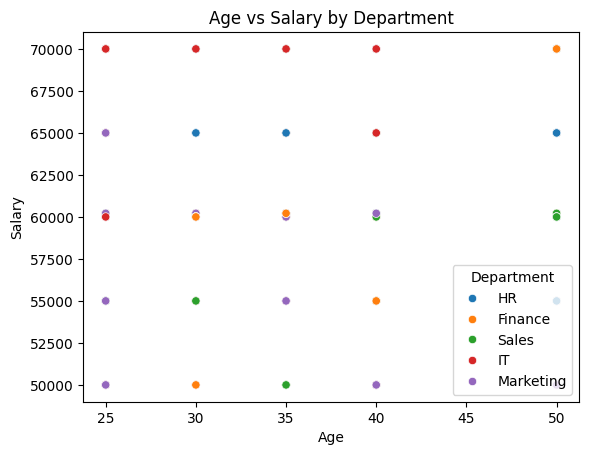

In [65]:
#Create a scatter plot showing Age vs Salary, with different colors for each department.

sns.scatterplot(data = df , x = "Age" , y = "Salary" , hue = "Department" ) 
plt.title("Age vs Salary by Department")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

Salary values are distributed across different age groups in all departments. There is no clear upward or downward pattern between age and salary. The salary levels appear at similar ranges across different departments and ages.

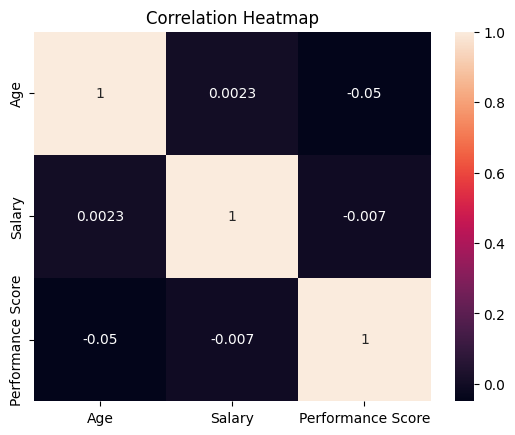

In [68]:
# Correlation Analysis
corr = df[["Age" , "Salary" , "Performance Score"]].corr()

sns.heatmap(corr , annot = True)
plt.title("Correlation Heatmap")
plt.show()

There is almost no linear relationship between Age and Salary in this dataset.

## Conclusion

The HR dataset was cleaned and analyzed to understand employee demographics, salaries, performance scores, departments, positions, and joining trends. The analysis showed that employee distribution across genders was relatively balanced, while most employees were between 35 and 40 years old. Salary distribution was mainly concentrated around ₹58,000–₹62,000.

The average salaries across departments and positions were relatively similar. The number of employees joining the company increased from 2018 to 2020, with 2020 having the highest number of joinings. The correlation analysis also showed an almost negligible relationship between Age and Salary. Overall, the analysis provided useful insights into employee distribution, salary patterns, performance, and hiring trends.